In [2]:

!pip install -q yfinance
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# EU Gas Storage Signal vs TTF Prices

**Question:** Do deviations of EU gas storage from its seasonal norm predict TTF gas price moves, and could a simple rule trade it?

**Method:** Signal = storage fill % minus its average for the same day of year over the previous 5 years (past data only). Long TTF when storage is below normal, short when above. Signal lagged 2 days, 5bps cost per position change. Parameters were set in advance, not optimised.

**Sources:** GIE AGSI+ (storage), Yahoo Finance (TTF front-month futures). Needs a free GIE API key stored as a Colab secret named `GIE_KEY`.

**Caveat:** In-sample backtest with full-size positions. Yahoo's TTF series is not roll-adjusted (see the roll-day section).

/tmp/ipykernel_21262/3854916660.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download("TTF=F", start="2016-01-01")["Close"].squeeze()
[*********************100%***********************]  1 of 1 completed


Date
2017-10-23    18.090000
2017-10-24    17.959999
2017-10-25    18.110001
2017-10-26    18.070000
2017-10-27    18.150000
Name: TTF=F, dtype: float64
2243


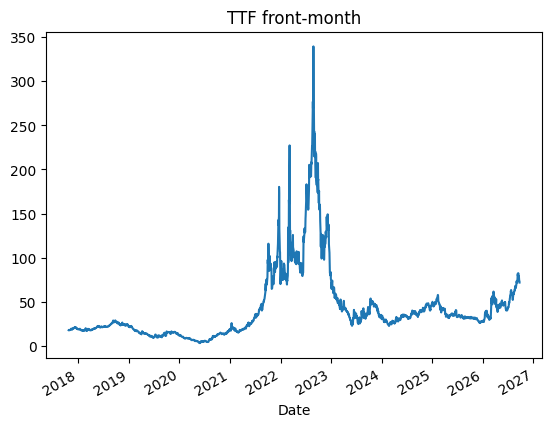

In [3]:
px = yf.download("TTF=F", start="2016-01-01")["Close"].squeeze()
print(px.head())
print(len(px))
px.plot(title="TTF front-month")
plt.show()


In [4]:
import requests, pandas as pd
from google.colab import userdata

key = userdata.get("GIE_KEY")
url = "https://agsi.gie.eu/api"
params = {"type": "eu", "from": "2016-01-01", "size": 300, "page": 1}

r = requests.get(url, headers={"x-key": key}, params=params)
print(r.status_code)
js = r.json()
print(js.keys())
print(js["data"][0] if "data" in js else js)


200
dict_keys(['last_page', 'total', 'dataset', 'gas_day', 'data'])
{'name': 'EU', 'code': 'eu', 'url': 'eu', 'updatedAt': '2026-09-23 14:10:03', 'gasDayStart': '2026-09-21', 'gasDayEnd': '2026-09-22', 'gasInStorage': '793.6866', 'consumption': '3519', 'consumptionFull': '22.55', 'injection': '2453.39', 'withdrawal': '231.5', 'netWithdrawal': '-2221.9', 'workingGasVolume': '1131.5658', 'injectionCapacity': '12228.71', 'withdrawalCapacity': '19924.41', 'contractedCapacity': '1040.4467', 'availableCapacity': '97.0229', 'coveredCapacity': '100', 'status': 'E', 'trend': '0.2', 'full': '70.14', 'info': []}


In [5]:
rows, page = [], 1
while True:
    params = {"type": "eu", "from": "2016-01-01", "size": 300, "page": page}
    js = requests.get(url, headers={"x-key": key}, params=params).json()
    rows += js["data"]
    if page >= js["last_page"]:
        break
    page += 1

raw = pd.DataFrame(rows)
print(raw.shape)
print(raw.columns.tolist())
print(raw.head(3))

(3917, 22)
['name', 'code', 'url', 'updatedAt', 'gasDayStart', 'gasDayEnd', 'gasInStorage', 'consumption', 'consumptionFull', 'injection', 'withdrawal', 'netWithdrawal', 'workingGasVolume', 'injectionCapacity', 'withdrawalCapacity', 'contractedCapacity', 'availableCapacity', 'coveredCapacity', 'status', 'trend', 'full', 'info']
  name code url            updatedAt gasDayStart   gasDayEnd gasInStorage  \
0   EU   eu  eu  2026-09-23 14:10:03  2026-09-21  2026-09-22     793.6866   
1   EU   eu  eu  2026-09-23 13:20:03  2026-09-20  2026-09-21     791.4558   
2   EU   eu  eu  2026-09-23 09:20:23  2026-09-19  2026-09-20      787.821   

  consumption consumptionFull injection  ... workingGasVolume  \
0        3519           22.55   2453.39  ...        1131.5658   
1        3519           22.49   3740.06  ...        1131.5658   
2        3519           22.39   3651.94  ...        1131.5658   

  injectionCapacity withdrawalCapacity contractedCapacity availableCapacity  \
0          12228.71  

2016-01-01 00:00:00 2026-09-21 00:00:00 3917
gasDayStart
1 days    3916
Name: count, dtype: int64
missing values: 0


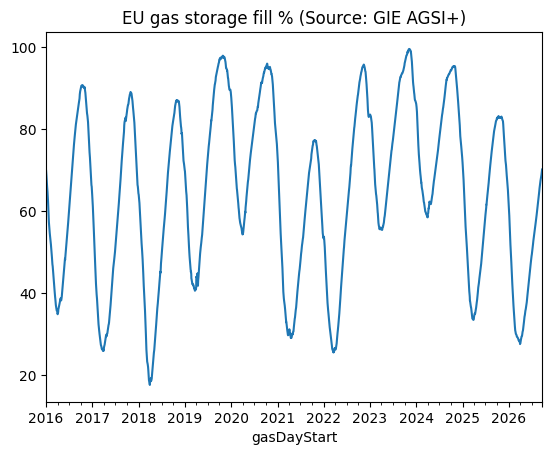

In [6]:
raw["gasDayStart"] = pd.to_datetime(raw["gasDayStart"])
raw["full"] = pd.to_numeric(raw["full"], errors="coerce")

storage = raw.set_index("gasDayStart").sort_index()["full"]
storage = storage[~storage.index.duplicated()]

print(storage.index.min(), storage.index.max(), len(storage))
print(storage.index.to_series().diff().value_counts().head())
print("missing values:", storage.isna().sum())
storage.plot(title="EU gas storage fill % (Source: GIE AGSI+)")
plt.show()

In [7]:
def seasonal_z(s, years=5):
    out = pd.Series(index=s.index, dtype=float)
    for d in s.index:
        hist = s[(s.index.dayofyear == d.dayofyear)
                 & (s.index.year < d.year)
                 & (s.index.year >= d.year - years)]
        out[d] = (s[d] - hist.mean()) / hist.std() if len(hist) >= 3 else np.nan
    return out

z = seasonal_z(storage)
print("z values calculated:", z.notna().sum(), "of", len(z))
print("first z date:", z.dropna().index.min())


z values calculated: 2819 of 3917
first z date: 2019-01-01 00:00:00


In [8]:
print("prices:", px.index.min(), "to", px.index.max(), len(px))

df = px.to_frame("px")
df["z"] = z.reindex(df.index).ffill()
df["ret"] = np.log(df["px"]).diff()
print(df.dropna().shape)
print(df.dropna().head(3))

# the 10 biggest daily moves (checking for futures roll gaps)
print(df["ret"].abs().sort_values(ascending=False).head(10))

prices: 2017-10-23 00:00:00 to 2026-09-23 00:00:00 2243
(1944, 3)
                   px         z       ret
Date                                     
2019-01-02  22.475000  1.130385  0.022271
2019-01-03  22.254999  1.077446 -0.009837
2019-01-04  22.930000  1.072793  0.029879
Date
2022-02-24    0.412784
2022-02-25    0.352421
2026-03-02    0.331170
2022-03-09    0.319475
2019-09-30    0.316777
2022-03-02    0.307886
2021-12-23    0.265390
2023-08-09    0.248331
2020-08-28    0.230557
2020-05-29    0.222574
Name: ret, dtype: float64


In [9]:
suspect = pd.to_datetime(["2019-09-30", "2020-05-29", "2020-08-28"])
for d in suspect:
    print(df.loc[d - pd.Timedelta(days=4): d + pd.Timedelta(days=4), ["px", "ret"]].round(3), "\n")

# any other big moves landing on the last business day of a month?
big = df[df["ret"].abs() > 0.10].copy()
big["last_bday_of_month"] = big.index.month != (big.index + pd.offsets.BDay(1)).month
print(big[["px", "ret", "last_bday_of_month"]].round(3))

                px    ret
Date                     
2019-09-26  12.045  0.008
2019-09-27  11.940 -0.009
2019-09-30  16.390  0.317
2019-10-01  16.760  0.022
2019-10-02  16.005 -0.046
2019-10-03  16.010  0.000
2019-10-04  15.770 -0.015 

               px    ret
Date                    
2020-05-26  4.125  0.059
2020-05-27  3.695 -0.110
2020-05-28  3.510 -0.051
2020-05-29  4.385  0.223
2020-06-01  4.055 -0.078
2020-06-02  4.850  0.179 

                px    ret
Date                     
2020-08-24   8.360  0.093
2020-08-25   8.865  0.059
2020-08-26   9.150  0.032
2020-08-27   8.870 -0.031
2020-08-28  11.170  0.231
2020-08-31  11.240  0.006
2020-09-01  11.295  0.005 

                px    ret  last_bday_of_month
Date                                         
2018-02-28  17.350 -0.101                True
2019-04-05  16.635  0.117               False
2019-07-16  11.415 -0.122               False
2019-07-31  11.000  0.117                True
2019-08-01  12.360  0.117               False
... 

                  Strategy (roll days removed)  Strategy (raw)  \
ann_log_return                           0.715           0.615   
vol                                      0.831           0.847   
sharpe                                   0.861           0.726   
max_drawdown (%)                        -0.829          -0.882   

                  Buy & hold (roll days removed)  
ann_log_return                             0.049  
vol                                        0.832  
sharpe                                     0.058  
max_drawdown (%)                          -0.932  


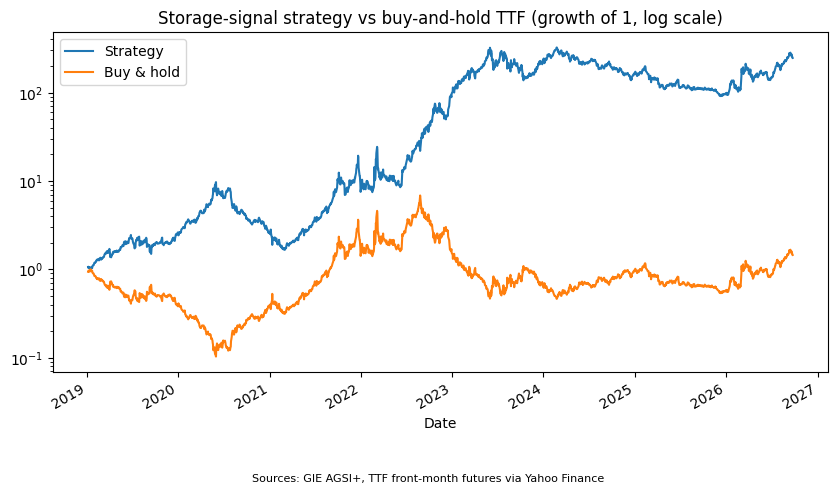

In [14]:
ROLL = ["2019-09-30", "2020-05-29", "2020-08-28"]

def make_frame(z_, roll):
    d = px.to_frame("px")
    d["z"] = z_.reindex(d.index).ffill()
    d["ret"] = np.log(d["px"]).diff()
    d.loc[d.index.isin(pd.to_datetime(roll)), "ret"] = 0   # neutralise suspected roll jumps
    return d

def backtest(d, lag=2, cost=0.0005):
    d = d.copy()
    d["pos"] = np.sign(-d["z"]).shift(lag)        # long if storage below norm, short if above
    d["strat"] = d["pos"] * d["ret"] - cost * d["pos"].diff().abs()
    return d.dropna(subset=["strat", "ret"])

def stats(r):
    ann, vol = r.mean() * 252, r.std() * np.sqrt(252)
    cum = r.cumsum()
    return pd.Series({"ann_log_return": ann, "vol": vol, "sharpe": ann / vol,
                      "max_drawdown (%)": np.exp(cum - cum.cummax()).min() - 1})

res = backtest(make_frame(z, ROLL))
raw_res = backtest(make_frame(z, []))

main = pd.DataFrame({
    "Strategy (roll days removed)": stats(res["strat"]),
    "Strategy (raw)": stats(raw_res["strat"]),
    "Buy & hold (roll days removed)": stats(res["ret"]),
}).round(3)
print(main)
main.to_csv("results_main.csv")

eq = np.exp(res[["strat", "ret"]].cumsum())
eq.columns = ["Strategy", "Buy & hold"]
ax = eq.plot(figsize=(10, 5), logy=True,
             title="Storage-signal strategy vs buy-and-hold TTF (growth of 1, log scale)")
plt.figtext(0.5, -0.02, "Sources: GIE AGSI+, TTF front-month futures via Yahoo Finance", ha="center", fontsize=8)
plt.savefig("equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()



In [11]:
tables = {}

periods = {"2019-21": ("2019-01-01", "2021-12-31"), "2022": ("2022-01-01", "2022-12-31"),
           "2023-25": ("2023-01-01", "2025-12-31"), "2026 YTD": ("2026-01-01", "2026-12-31")}
tables["by_period"] = pd.DataFrame({k: stats(res["strat"].loc[a:b]) for k, (a, b) in periods.items()})
tables["ex_2022"] = pd.DataFrame({"excluding 2022": stats(res[res.index.year != 2022]["strat"])})

best10 = res["strat"].sort_values(ascending=False).head(10)
print("Share of total P&L from the 10 best days:", round(best10.sum() / res["strat"].sum(), 2))
print(res.groupby("pos")["strat"].agg(["count", "sum"]).round(3), "\n")   # long vs short contribution

z3, z7 = seasonal_z(storage, 3), seasonal_z(storage, 7)
tables["lookback"] = pd.DataFrame({
    "3y": stats(backtest(make_frame(z3, ROLL))["strat"]),
    "5y": stats(res["strat"]),
    "7y": stats(backtest(make_frame(z7, ROLL))["strat"])})

tables["roll_days"] = pd.DataFrame({
    "no fix": stats(raw_res["strat"]),
    "2 clear days": stats(backtest(make_frame(z, ["2019-09-30", "2020-08-28"]))["strat"]),
    "all 3": stats(res["strat"])})

f = make_frame(z, ROLL)
tables["lag_days"] = pd.DataFrame({f"lag {l}": stats(backtest(f, lag=l)["strat"]) for l in [1, 2, 5]})
tables["cost"] = pd.DataFrame({f"{c*1e4:.0f}bps": stats(backtest(f, cost=c)["strat"]) for c in [0, 0.0005, 0.002]})

for name, t in tables.items():
    print("\n==", name, "==")
    print(t.round(3))
    t.round(3).to_csv(f"results_{name}.csv")

Share of total P&L from the 10 best days: 0.45
      count    sum
pos               
-1.0   1079  2.567
 1.0    862  2.941 


== by_period ==
                  2019-21   2022  2023-25  2026 YTD
ann_log_return      0.675  2.570   -0.003     1.300
vol                 0.751  1.317    0.677     0.850
sharpe              0.898  1.952   -0.005     1.530
max_drawdown (%)   -0.829 -0.650   -0.719    -0.373

== ex_2022 ==
                  excluding 2022
ann_log_return             0.440
vol                        0.731
sharpe                     0.602
max_drawdown (%)          -0.829

== lookback ==
                     3y     5y     7y
ann_log_return    0.628  0.715  0.686
vol               0.831  0.831  0.831
sharpe            0.756  0.861  0.826
max_drawdown (%) -0.756 -0.829 -0.829

== roll_days ==
                  no fix  2 clear days  all 3
ann_log_return     0.615         0.686  0.715
vol                0.847         0.835  0.831
sharpe             0.726         0.822  0.861
max_drawdow

same sign as z-score: 1.0


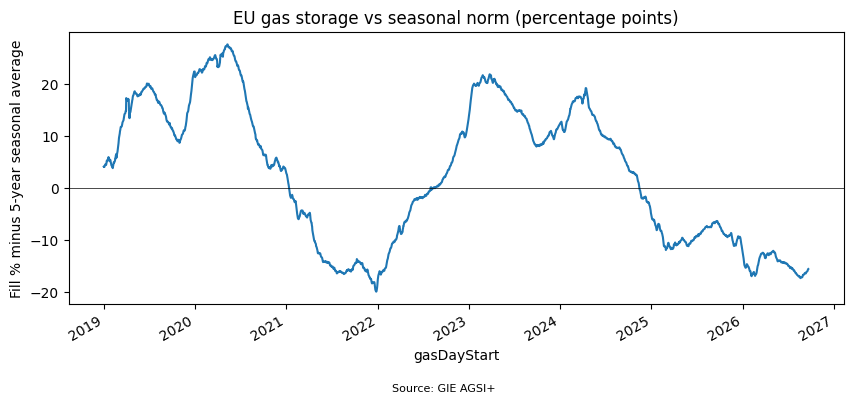

position flips: 7 | share of days long: 0.44


In [12]:
def seasonal_dev(s, years=5):
    """Storage minus its average for the same day of year over the previous `years` years (percentage points)."""
    doy, yr, v = s.index.dayofyear.values, s.index.year.values, s.values
    out = np.full(len(s), np.nan)
    for i in range(len(s)):
        m = (doy == doy[i]) & (yr < yr[i]) & (yr >= yr[i] - years)
        if m.sum() >= 3:
            out[i] = v[i] - v[m].mean()
    return pd.Series(out, index=s.index)

dev = seasonal_dev(storage)

# proof that the trading signal is identical to the z-score version
both = z.notna() & dev.notna()
print("same sign as z-score:", (np.sign(z[both]) == np.sign(dev[both])).mean())

ax = dev.dropna().plot(figsize=(10, 4), title="EU gas storage vs seasonal norm (percentage points)")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Fill % minus 5-year seasonal average")
plt.figtext(0.5, -0.02, "Source: GIE AGSI+", ha="center", fontsize=8)
plt.savefig("storage_deviation.png", dpi=150, bbox_inches="tight")
plt.show()

print("position flips:", int((res["pos"].diff().abs() > 0).sum()),
      "| share of days long:", round((res["pos"] > 0).mean(), 2))

In [13]:
p = res["pos"]
ep_id = (p != p.shift()).cumsum()
dates = res.index.to_series().groupby(ep_id)
g = res.groupby(ep_id)
eps = pd.DataFrame({
    "start": dates.first().dt.date,
    "end": dates.last().dt.date,
    "position": g["pos"].first().map({1.0: "long", -1.0: "short"}),
    "days": g.size(),
    "strategy_log_return": g["strat"].sum(),
    "ttf_log_return": g["ret"].sum(),
}).round(2)
print(eps)
print("episodes:", len(eps), "| profitable:", int((eps["strategy_log_return"] > 0).sum()))

          start         end position  days  strategy_log_return  \
pos                                                               
1    2019-01-07  2021-01-13    short   510                 0.83   
2    2021-01-14  2022-08-02     long   390                 2.25   
3    2022-08-03  2022-08-08    short     4                 0.06   
4    2022-08-09  2022-08-16     long     6                 0.16   
5    2022-08-17  2022-08-19    short     3                -0.08   
6    2022-08-22  2022-08-23     long     2                 0.09   
7    2022-08-24  2024-11-15    short   562                 1.75   
8    2024-11-18  2026-09-23     long   464                 0.44   

     ttf_log_return  
pos                  
1             -0.83  
2              2.26  
3             -0.06  
4              0.16  
5              0.08  
6              0.10  
7             -1.75  
8              0.44  
episodes: 8 | profitable: 7


In [15]:
storage.to_csv("eu_storage.csv")
from google.colab import files
files.download("eu_storage.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



> Add blockquote

